# 20260611
- Pick frames from cal files and fit power law
    - for each sensitivity
- Apply calibrations to test results and compare accross sensitivities

In [1]:
from pathlib import Path
import numpy as np

from phd_helpers.experiments import get_instron_data, get_frame_at_F, parse_tekscan, force_per_frame

In [35]:
path = Path('../../../LabData/MethodDevelopment/tekscanCalibration/20260611')
sensor = 3
Fmax = 210
Fmin = 30
sens = {
    'high2': {
        'cal_Fs': np.arange(Fmin, Fmax, 10),
        'test_Fs': np.arange(10, 60, 10),
        'mask': 8
    },
    'high1': {
        'cal_Fs': np.arange(Fmin, Fmax, 10),
        'test_Fs': np.arange(10, 160, 10),
        'mask': 2
    },
    'mid2': {
        'cal_Fs': np.arange(Fmin, Fmax, 10),
        'test_Fs': np.arange(10, 160, 10),
        'mask': 0
    }
}

In [36]:
from scipy.optimize import minimize_scalar
def compute_power_law_coeffs(cal_frames, sensel_area=1.6129, return_fit_points=False, mask=0):
    """
    P = a r^b

    P is pressure, r is sensel raw 8-bit value.
    Fit is done at patch level:
        p_i ≈ a * mean(x_i ** b)
    """

    patches = [x for x in cal_frames.values()]
    Fs = np.array([x for x in cal_frames.keys()], dtype=float)

    xs = [
        np.asarray(p, dtype=float)[np.asarray(p, dtype=float) > mask]
        for p in patches
    ]

    n = np.array([len(x) for x in xs], dtype=float)
    area = n * sensel_area
    p = Fs / area

    def S(b):
        return np.array([np.mean(x ** b) for x in xs])

    def a_of_b(b):
        s = S(b)
        w = area ** 2
        return np.dot(w * p, s) / np.dot(w * s, s)

    def J(b):
        s = S(b)
        a = a_of_b(b)
        return np.sum((area * (a * s - p)) ** 2)

    res = minimize_scalar(J, bounds=(0, 3), method="bounded")

    b = res.x
    a = a_of_b(b)

    if not return_fit_points:
        return a, b

    s = S(b)
    p_fit = a * s

    # Effective raw value for each calibration patch
    r_eff = s ** (1 / b)

    fit_points = {
        "raw_eff": r_eff,
        "pressure_actual": p,
        "pressure_fit": p_fit,
        "force": Fs,
        "area": area,
        "n_sensels": n,
    }

    return a, b, fit_points

In [37]:
def get_frames(test_cal, sen, cal_Fs):
    instron_path = list(path.glob(f'{test_cal}-*{sen}*/*'))[0]
    instron_data = get_instron_data(instron_path)

    tekscan_path = path / f'{test_cal}-{sen}.asm'
    header, (_, _, tekscan_data, _) = parse_tekscan(tekscan_path)

    return {F: tekscan_data[get_frame_at_F(F, instron_data, header)] for F in cal_Fs}

def mask_raw_frames(frames_dict, mask_value):
    return {key: np.where(val <= mask_value, 0, val) for key, val in frames_dict.items()}

5.035943117187799
4.787902250742211
4.409903283414058


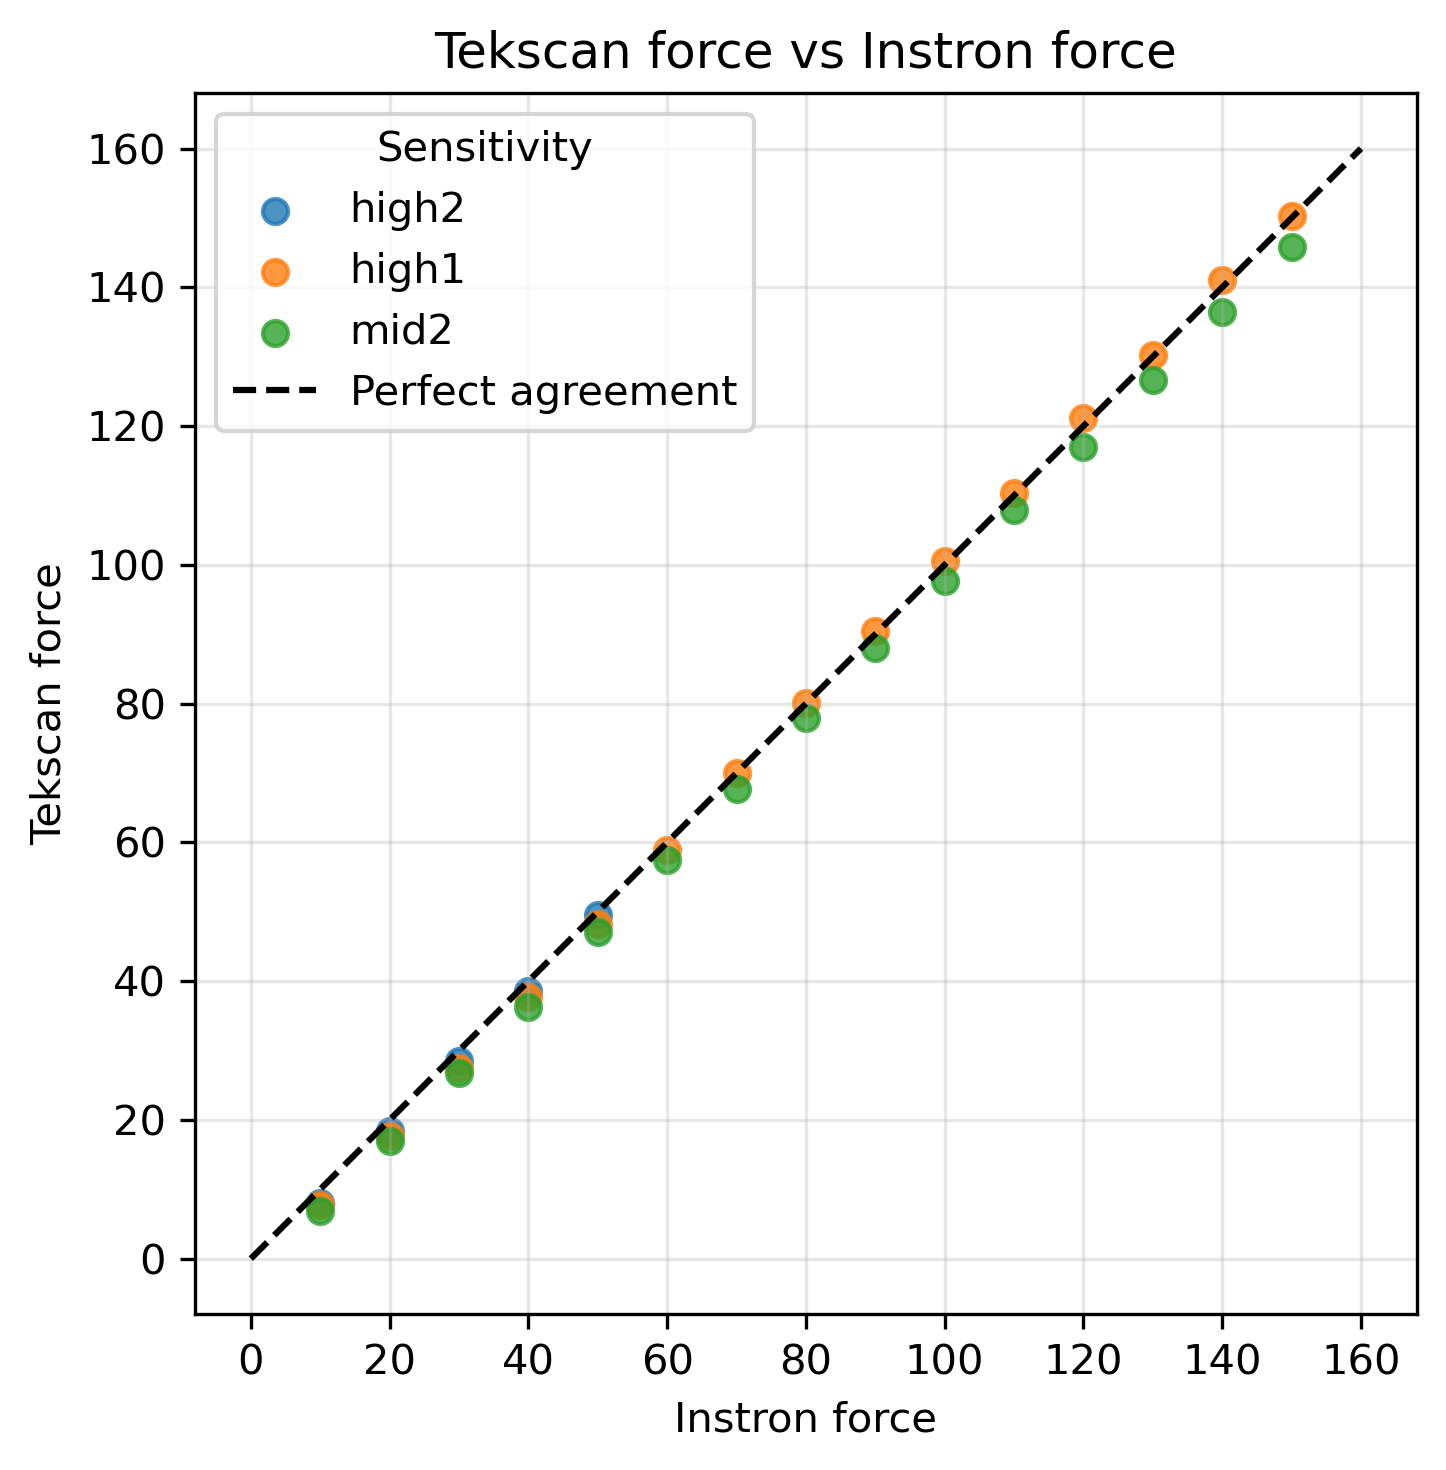

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

all_ab = []

for sen, sen_dict in sens.items():
    instron_forces = []
    tekscan_forces = []

    cal_frames = get_frames('cal', sen, sen_dict['cal_Fs'])
    cal_frames = mask_raw_frames(cal_frames, sen_dict['mask']) # mask cal frames
    test_frames = get_frames('test', sen, sen_dict['test_Fs'])
    test_frames = mask_raw_frames(test_frames, sen_dict['mask']) # mask test frames

    a, b = compute_power_law_coeffs(cal_frames)
    test_frames_mpa = {f: a * x**b for f, x in test_frames.items()}
    print(test_frames_mpa[50].max())

    for F, frame in test_frames_mpa.items():
        tekscan_force = force_per_frame(frame.reshape(1, 11, 11))[0]

        instron_forces.append(F)
        tekscan_forces.append(tekscan_force)

        fname = f'moreCalibration/{F}-frames_mpa-{sen}.txt'
        np.savetxt(fname, frame)

    all_ab.append((a, b))

    ax.scatter(instron_forces, tekscan_forces, alpha=0.8, label=str(sen))

ax.plot([0, 160], [0, 160], linestyle='--', color='black', label='Perfect agreement')

ax.set_xlabel('Instron force')
ax.set_ylabel('Tekscan force')
ax.set_title('Tekscan force vs Instron force')
ax.legend(title='Sensitivity')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Best results accross all sensitivities when using around 0 - 300 N force
- because approximate contact area of tpm is 50ish and contact area of calibration block is 100 so double the force gives same pressure range?

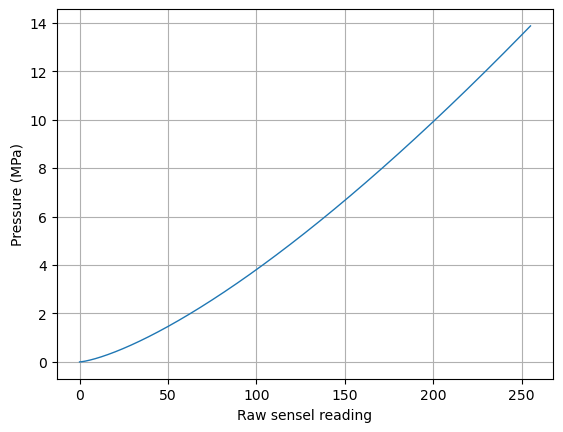

In [43]:
fig, ax = plt.subplots()

xs = np.linspace(0, 255, 1000)
a, b = all_ab[1]
ys = (a*xs**b)
ax.plot(xs, ys, linewidth=1)

ax.set_xlabel('Raw sensel reading')
ax.set_ylabel('Pressure (MPa)')
ax.grid()
plt.show()

# Fig for presentation

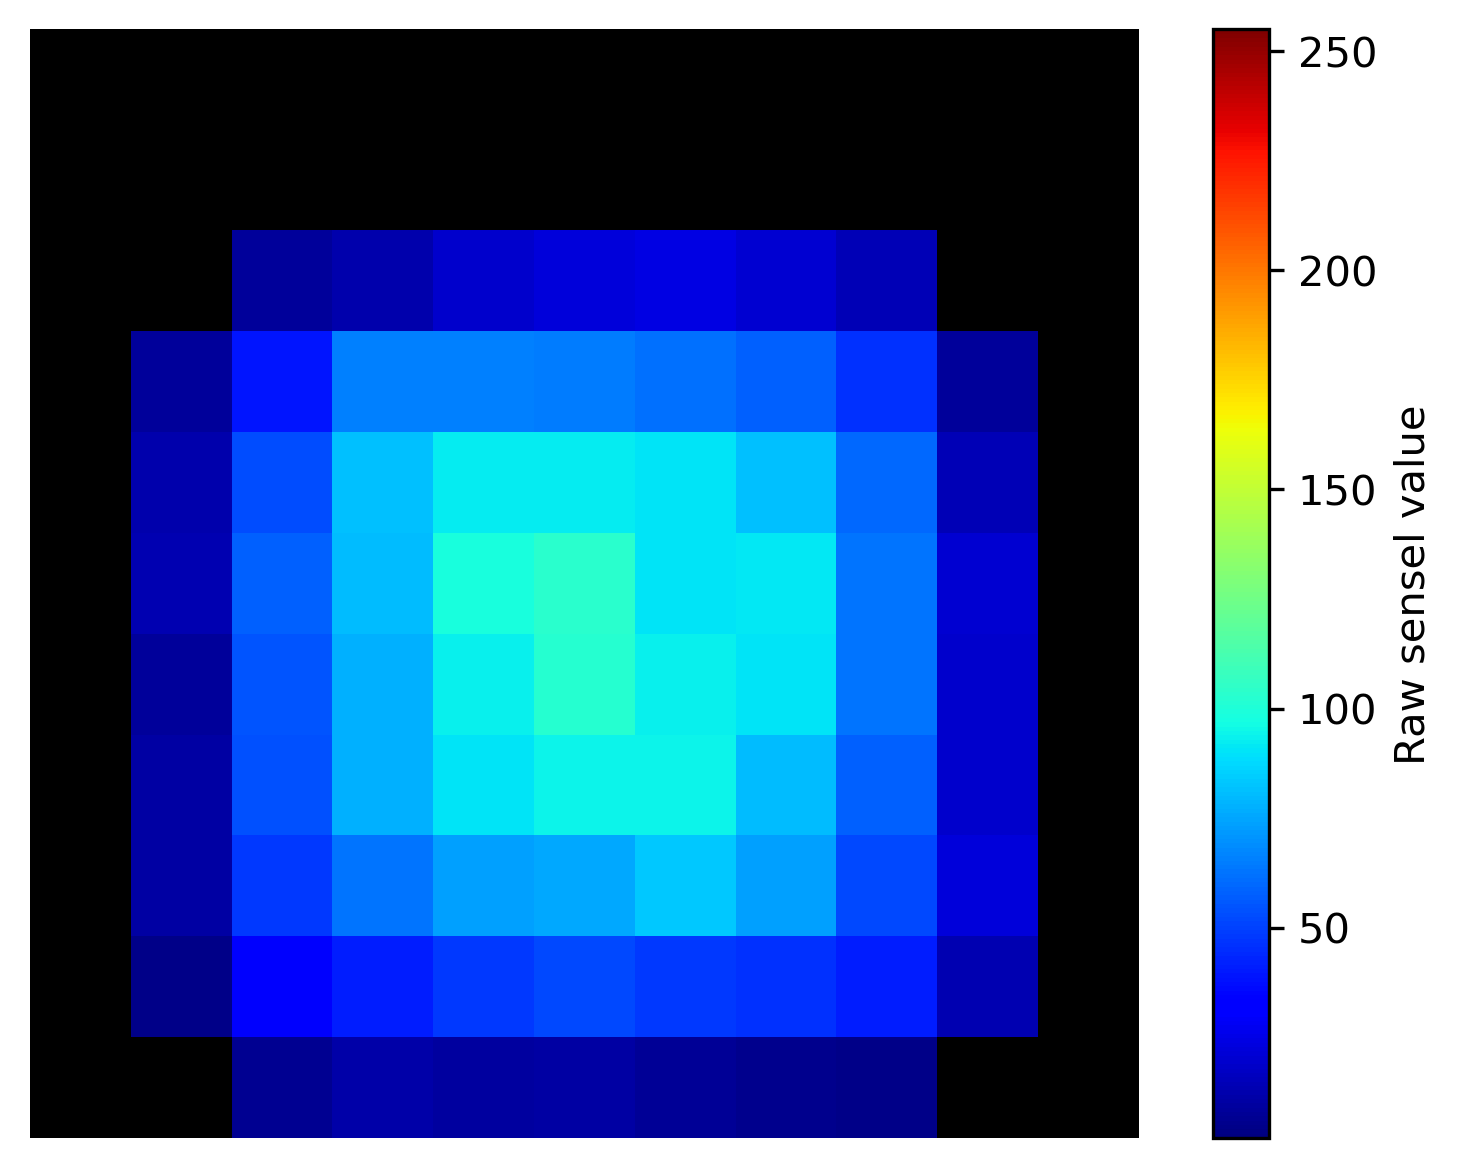

In [42]:
fig, ax = plt.subplots(1,1, dpi=300)
sen = 'high1'
F = 200
sen_dict = sens[sen]
frames = get_frames('cal', sen, sen_dict['cal_Fs'])
frames = mask_raw_frames(frames, sen_dict['mask'])
cmap = plt.cm.jet.copy()
cmap.set_under('black')
im = ax.imshow(frames[F], cmap=cmap, vmin=sen_dict['mask'], vmax=255)
cbar = fig.colorbar(im, ax=ax) 
cbar.set_label('Raw sensel value') 
ax.axis('off')
plt.show()